# SaaSFlow | Predicción del MRR mensual del próximo trimestre

**Autores:** Renato Acosta, Bruno Aldana, Alanis Figueroa, Benjamin Jara

**Fecha de Creación:** Septiembre de 2026  

---

## Descripción


**Objetivo:** estimar `mrr_proximo_trimestre` en USD por cliente, siguiendo las cuatro fases de la evaluación E2. El objetivo es un **importe mensual esperado durante el próximo trimestre**, no la suma de tres meses. Ejecuta las celdas en orden en Google Colab. Se conserva la carga solicitada del archivo `clientes_mrr_dataset.csv`; si la descarga no funciona, se permite subir el CSV adjunto.

Las métricas se calculan al ejecutar el notebook: no se reutilizan cifras fijas de otra ejecución. La fecha de referencia representa el instante del pronóstico para este conjunto de datos; para un período futuro distinto hará falta volver a definir el corte y validar con datos fechados.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12.3 A continuación se listan las bibliotecas necesarias:

- pandas
- numpy
- matplotlib
- seaborn
- scipy
- scikit-learn


# **1. Fase 1: Diagnóstico y Calidad de Datos**

## 1.1 Metadata

| Variable | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| *id_cliente* | Cadena | Identificador único de cliente |
| *fecha_registro* | Texto / Date | Fecha de alta del cliente |
| *sector_empresa* | Categórica | Sector de la empresa (Tecnología, Finanzas, Salud, Retail, Educación) |
| *tamano_empresa* | Categórica | Dimensión (Pequeña, Mediana, Grande) |
| *tickets_soporte* | Numérica (Entero) | Número de tickets abiertos en los últimos 6 meses |
| *promedio_sesiones_mes* | Numérica (Flotante) | Sesiones de uso mensuales promedio de la plataforma |
| *satisfaccion_nps* | Numérica (Entero) | Puntaje NPS de 1 a 10 |
| *duracion_contrato* | Categórica | Tipo de suscripción (Mensual, Anual, 2 Años) |
| *gasto_mkt_asociado* | Numérica (Flotante) | Inversión en marketing para captar/retener al cliente |
| *pago_puntual* | Categórica | Si el cliente suele pagar a tiempo (Si, No) |
| ***mrr_proximo_trimestre*** | Numérica (Flotante) | **Variable Objetivo (Y):** ingreso mensual esperado en USD |

> **Nota sobre la metadata:** el enunciado indica identificadores `CLI-0001` a `CLI-2000`, pero el archivo real contiene más registros, y los sectores vienen sin tilde (`Tecnologia`, `Educacion`). Ambas diferencias se verifican con código en la sección 1.6 y no afectan al modelo.

## 1.2 Carga de Datos

In [1]:
import os
import subprocess
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

try:
    from IPython.display import display
except ImportError:
    display = print  # Permite ejecutar también fuera de Colab/Jupyter.

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

# ---------------- Constantes globales (se definen UNA sola vez) ----------------
SEMILLA = 42
OBJETIVO = 'mrr_proximo_trimestre'
FECHA_REFERENCIA = pd.Timestamp('2026-01-01')   # instante del pronóstico
MAPA_DURACION = {'Mensual': 1, 'Anual': 12, '2 Años': 24}   # meses de compromiso
MAPA_PAGO = {'No': 0, 'Si': 1}
COLS_NUMERICAS_CRUDAS = ['tickets_soporte', 'promedio_sesiones_mes',
                         'satisfaccion_nps', 'gasto_mkt_asociado', OBJETIVO]


# ---------------- Descarga del dataset ----------------
archivo_csv = 'clientes_mrr_dataset.csv'
URL_CSV = ('https://raw.githubusercontent.com/alanis1328/Inteligencia-Artificial-620454/'
           'main/E2%20-%20Regresion/clientes_mrr_dataset.csv')

if not os.path.exists(archivo_csv):
    subprocess.run(['wget', '-q', '-O', archivo_csv, URL_CSV], check=False)
    if os.path.exists(archivo_csv) and os.path.getsize(archivo_csv) == 0:
        os.remove(archivo_csv)

# Alternativa para Colab si la descarga no está disponible.
if not os.path.exists(archivo_csv):
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(f'Coloca {archivo_csv} junto al notebook.') from exc
    print(f'Sube el archivo {archivo_csv} desde tu equipo.')
    subidos = files.upload()
    if archivo_csv not in subidos:
        raise FileNotFoundError(f'No se recibió {archivo_csv}.')

df = pd.read_csv(archivo_csv)
print(f'\nDimensiones: {df.shape[0]:,} clientes y {df.shape[1]} columnas.')
display(df.head())


Dimensiones: 30,000 clientes y 11 columnas.


,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
0,CLI-0001,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.000,34.351,7.000,Mensual,"3,932.342",Si,706.160
1,CLI-0002,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.686,8.000,Mensual,"2,547.833",No,555.950
2,CLI-0003,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.000,50.027,7.000,2 Años,"3,203.233",Si,755.530
3,CLI-0004,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.000,NaN,9.000,Anual,603.209,No,364.940
4,CLI-0005,2021-09-26 05:21:16.482549416,Educacion,Grande,3.000,NaN,8.000,Anual,864.789,Si,"1,611.930"


## 1.3 Detección de Tipos de Datos y Nulos

Tipos de datos: la fecha y las categóricas llegan como texto y deben transformarse


,dtype_leido,tipo_esperado,requiere_tratamiento
id_cliente,str,texto,No
fecha_registro,str,fecha,Sí: llega como texto
sector_empresa,str,categórica,Sí: llega como texto
tamano_empresa,str,categórica,Sí: llega como texto
tickets_soporte,float64,numérica,No
promedio_sesiones_mes,float64,numérica,No
satisfaccion_nps,float64,numérica,No
duracion_contrato,str,categórica,Sí: llega como texto
gasto_mkt_asociado,float64,numérica,No
pago_puntual,str,categórica,Sí: llega como texto


Valores nulos por variable:


,nulos,porcentaje
satisfaccion_nps,3597,11.990
tickets_soporte,2464,8.213
promedio_sesiones_mes,1545,5.150
sector_empresa,0,0.000
fecha_registro,0,0.000
id_cliente,0,0.000
tamano_empresa,0,0.000
duracion_contrato,0,0.000
gasto_mkt_asociado,0,0.000
pago_puntual,0,0.000


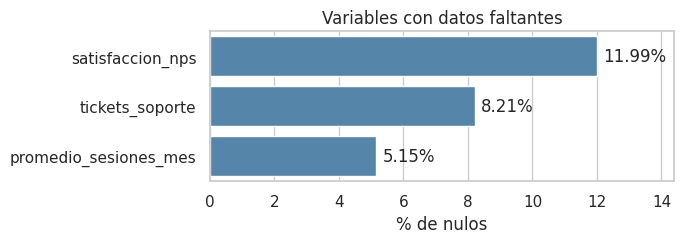

Filas con al menos un nulo: 23.5%


In [2]:
PREDICTORES = ['fecha_registro', 'sector_empresa', 'tamano_empresa', 'tickets_soporte',
               'promedio_sesiones_mes', 'satisfaccion_nps', 'duracion_contrato',
               'gasto_mkt_asociado', 'pago_puntual']
faltantes = ({'id_cliente', OBJETIVO, *PREDICTORES}) - set(df.columns)
if faltantes:
    raise ValueError(f'Columnas obligatorias ausentes: {sorted(faltantes)}')

# 1) Tipos leídos vs. tipos esperados según la metadata
esperado = {'id_cliente': 'texto', 'fecha_registro': 'fecha', 'sector_empresa': 'categórica',
            'tamano_empresa': 'categórica', 'tickets_soporte': 'numérica', 'promedio_sesiones_mes': 'numérica',
            'satisfaccion_nps': 'numérica', 'duracion_contrato': 'categórica', 'gasto_mkt_asociado': 'numérica',
            'pago_puntual': 'categórica', OBJETIVO: 'numérica'}
tipos = pd.DataFrame({'dtype_leido': df.dtypes.astype(str), 'tipo_esperado': pd.Series(esperado)})
tipos['requiere_tratamiento'] = np.where(
    (tipos.tipo_esperado == 'fecha') | (tipos.tipo_esperado == 'categórica'),
    'Sí: llega como texto', 'No')
print('Tipos de datos: la fecha y las categóricas llegan como texto y deben transformarse')
display(tipos)

# 2) Porcentaje de nulos por variable
nulos = pd.DataFrame({'nulos': df.isna().sum(), 'porcentaje': 100 * df.isna().mean()})
nulos = nulos.sort_values('porcentaje', ascending=False)
print('Valores nulos por variable:')
display(nulos)

con_nulos = nulos[nulos.nulos > 0]
fig, ax = plt.subplots(figsize=(7, 2.6))
sns.barplot(x=con_nulos.porcentaje, y=con_nulos.index, color='#4887b8', ax=ax)
for i, v in enumerate(con_nulos.porcentaje):
    ax.text(v + 0.2, i, f'{v:.2f}%', va='center')
ax.set_xlabel('% de nulos'); ax.set_ylabel('')
ax.set_title('Variables con datos faltantes'); ax.set_xlim(0, con_nulos.porcentaje.max() * 1.2)
plt.tight_layout(); plt.show()

print(f"Filas con al menos un nulo: {df.isna().any(axis=1).mean():.1%}")

In [3]:
filas = []
for col in ['tickets_soporte', 'promedio_sesiones_mes', 'satisfaccion_nps']:
    falta = df[col].isna()
    con, sin = df.loc[falta, OBJETIVO], df.loc[~falta, OBJETIVO]
    t, p = stats.ttest_ind(con, sin, equal_var=False)
    filas.append({'variable': col, 'MRR medio si falta': con.mean(), 'MRR medio si NO falta': sin.mean(),
                  'diferencia (USD)': con.mean() - sin.mean(), 'p-valor': p})
tabla_nulos = pd.DataFrame(filas).set_index('variable')
display(tabla_nulos)

if (tabla_nulos['p-valor'] > 0.05).all():
    print('Conclusión: no hay diferencias significativas de MRR (p > 0,05) entre clientes con y sin dato. '
          'Esto solo descarta dependencia respecto del MRR, no respecto de los predictores; se adopta la imputación '
          'simple (mediana/moda) como supuesto razonable. Es un diagnóstico: no se usa para ajustar ningún paso del modelo.')
else:
    print('Atención: algún nulo se asocia con el MRR; evaluar agregar indicadores de dato faltante.')

,MRR medio si falta,MRR medio si NO falta,diferencia (USD),p-valor
variable,,,,
tickets_soporte,710.778,710.940,-0.162,0.982
promedio_sesiones_mes,710.591,710.945,-0.354,0.967
satisfaccion_nps,708.258,711.290,-3.032,0.604


Conclusión: no hay diferencias significativas de MRR (p > 0,05) entre clientes con y sin dato. Esto solo descarta dependencia respecto del MRR, no respecto de los predictores; se adopta la imputación simple (mediana/moda) como supuesto razonable. Es un diagnóstico: no se usa para ajustar ningún paso del modelo.


## 1.4 Detección de Atípicos y Sesgo


Se evaluaron las variables numéricas para identificar la presencia de valores extremos (outliers) y asimetrías mediante el cálculo del Rango Intercuartílico (IQR) y medidas de dispersión.

* **Hallazgos clave:**
  * Variables como `promedio_sesiones_mes` y `mrr_proximo_trimestre` presentan asimetría positiva notable y concentración de valores extremos que podrían corresponder a cuentas de alto rendimiento o uso intensivo de la plataforma.
  * Los puntos fuera de los límites del IQR no se consideran errores de captura, ya que la sección 1.6 no detecta valores imposibles (negativos, fuera de rango o mal formateados); se tratan como posibles comportamientos legítimos de negocio.
* **Decisión técnica:** Siguiendo las buenas prácticas, **no se eliminan** estos registros para evitar la pérdida de información valiosa. En su lugar, este diagnóstico justifica la elección de técnicas robustas en la Fase 2, tales como el uso de la **mediana** para la imputación de nulos y el `RobustScaler` para el escalado, mitigando así el sesgo ante estos valores extremos sin alterar la realidad de los datos.

,media,mediana,desv_est,asimetria,atipicos_IQR,porcentaje_atipicos
variable,,,,,,
tickets_soporte,3.010,3.000,1.730,0.570,328,1.090
promedio_sesiones_mes,50.130,36.230,45.060,1.970,1367,4.560
satisfaccion_nps,5.910,6.000,2.310,-0.420,0,0.000
gasto_mkt_asociado,"2,551.090","2,541.070","1,416.110",0.000,0,0.000
mrr_proximo_trimestre,710.930,642.600,337.690,1.050,607,2.020



REPORTE DETALLADO DE LÍMITES IQR

--- Análisis IQR para 'tickets_soporte' ---
Q1: 2.00 | Q3: 4.00 | IQR: 2.00
Límite Inf: -1.00 | Límite Sup: 7.00
Fuera de límites: 328 (1.09%)

--- Análisis IQR para 'promedio_sesiones_mes' ---
Q1: 18.09 | Q3: 67.45 | IQR: 49.36
Límite Inf: -55.96 | Límite Sup: 141.50
Fuera de límites: 1367 (4.56%)

--- Análisis IQR para 'satisfaccion_nps' ---
Q1: 4.00 | Q3: 8.00 | IQR: 4.00
Límite Inf: -2.00 | Límite Sup: 14.00
Fuera de límites: 0 (0.00%)

--- Análisis IQR para 'gasto_mkt_asociado' ---
Q1: 1330.53 | Q3: 3785.67 | IQR: 2455.14
Límite Inf: -2352.19 | Límite Sup: 7468.38
Fuera de límites: 0 (0.00%)

--- Análisis IQR para 'mrr_proximo_trimestre' ---
Q1: 458.99 | Q3: 896.71 | IQR: 437.72
Límite Inf: -197.60 | Límite Sup: 1553.29
Fuera de límites: 607 (2.02%)



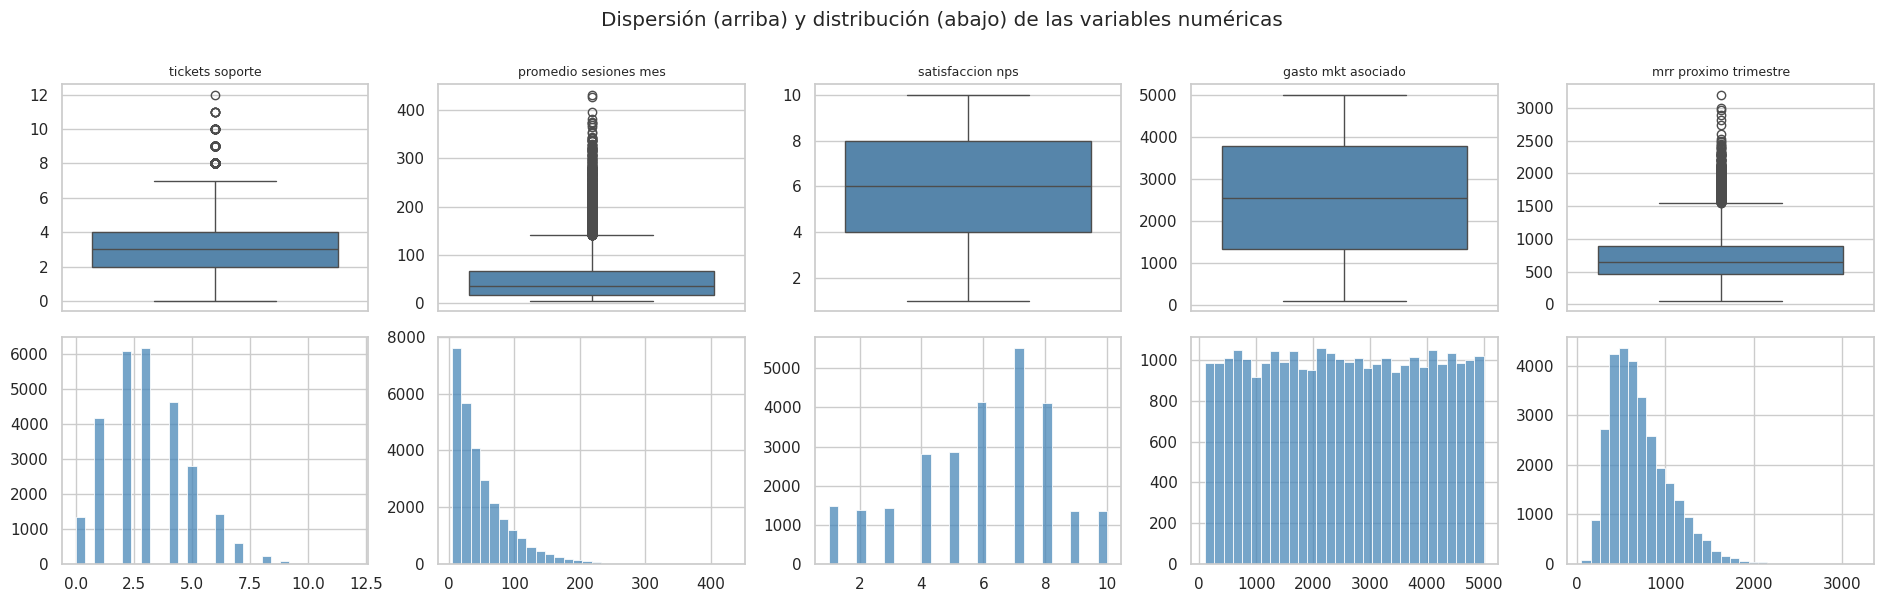

Variables con asimetría notable (|asimetría| > 0.5): ['tickets_soporte', 'promedio_sesiones_mes', 'mrr_proximo_trimestre']


In [4]:
# --- 1.4 DETECCIÓN DE ATÍPICOS (TABLA, IQR Y VISUALIZACIÓN) ---

def diagnostico_outliers_iqr(dataframe: pd.DataFrame, columna: str):
    serie = pd.to_numeric(dataframe[columna], errors='coerce')
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataframe[(serie < lower_bound) | (serie > upper_bound)]

    print(f"--- Análisis IQR para '{columna}' ---")
    print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"Límite Inf: {lower_bound:.2f} | Límite Sup: {upper_bound:.2f}")
    print(f"Fuera de límites: {len(outliers)} ({100 * len(outliers) / len(dataframe):.2f}%)\n")
    return outliers

# 1. Resumen estadístico completo con asimetría y conteo IQR
numericas_eda = ['tickets_soporte', 'promedio_sesiones_mes', 'satisfaccion_nps',
                 'gasto_mkt_asociado', OBJETIVO]
resumen = []
for nombre in numericas_eda:
    serie = pd.to_numeric(df[nombre], errors='coerce')
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    extremos = (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)
    resumen.append({'variable': nombre, 'media': serie.mean(), 'mediana': serie.median(),
                    'desv_est': serie.std(), 'asimetria': serie.skew(),
                    'atipicos_IQR': int(extremos.sum()), 'porcentaje_atipicos': 100 * extremos.mean()})

resumen_eda = pd.DataFrame(resumen).set_index('variable').round(2)
display(resumen_eda)

# 2. Ejecución de la función IQR detallada por consola para cada variable numérica
print("\n" + "="*50)
print("REPORTE DETALLADO DE LÍMITES IQR")
print("="*50 + "\n")
for col in numericas_eda:
    diagnostico_outliers_iqr(df, col)

# 3. Visualización dual: Boxplots (arriba) e Histogramas (abajo)
fig, axes = plt.subplots(2, len(numericas_eda), figsize=(19, 6))
for j, nombre in enumerate(numericas_eda):
    serie = pd.to_numeric(df[nombre], errors='coerce')
    sns.boxplot(y=serie, ax=axes[0, j], color='#4887b8')
    axes[0, j].set_title(nombre.replace('_', ' '), fontsize=9); axes[0, j].set_ylabel('')
    sns.histplot(serie.dropna(), bins=30, ax=axes[1, j], color='#4887b8')
    axes[1, j].set_xlabel(''); axes[1, j].set_ylabel('')

fig.suptitle('Dispersión (arriba) y distribución (abajo) de las variables numéricas', y=1.0)
plt.tight_layout(); plt.show()

# 4. Identificación automática de variables sesgadas
sesgadas = resumen_eda[resumen_eda.asimetria.abs() > 0.5].index.tolist()
print('Variables con asimetría notable (|asimetría| > 0.5):', sesgadas)

## 1.5 Detección de Duplicados

In [5]:
print('--- Análisis de Duplicados ---')
print(f"IDs de cliente duplicados: {df['id_cliente'].duplicated().sum()}")
print(f"Filas exactamente duplicadas (todas las columnas): {df.duplicated().sum()}")
print(f"Filas duplicadas ignorando el ID (mismo perfil y mismo MRR): "
      f"{df.drop(columns='id_cliente').duplicated().sum()}")

--- Análisis de Duplicados ---
IDs de cliente duplicados: 0
Filas exactamente duplicadas (todas las columnas): 0
Filas duplicadas ignorando el ID (mismo perfil y mismo MRR): 0


## 1.6 Detección de Datos Inconsistentes

Se definen como inconsistentes los siguientes casos, **todos verificados con código** en la celda siguiente:

1. **Fechas:** `fecha_registro` que no se pueda convertir a fecha, o posterior a la fecha de corte (`2026-01-01`). Una fecha futura produciría una antigüedad negativa.
2. **Numéricas:** texto en columnas numéricas, valores negativos, `satisfaccion_nps` fuera del rango 1–10 según la metadata, `tickets_soporte` no entero y `mrr_proximo_trimestre` ≤ 0.
3. **Categóricas:** categorías fuera del dominio de la metadata en `duracion_contrato`, `pago_puntual` y `tamano_empresa`.
4. **Identificadores:** formato distinto de `CLI-####`.

In [6]:
fechas = pd.to_datetime(df['fecha_registro'], errors='coerce')
nums = {c: pd.to_numeric(df[c], errors='coerce') for c in COLS_NUMERICAS_CRUDAS}

reglas = [
    ('Fechas no convertibles a fecha',           int(fechas.isna().sum())),
    ('Fechas posteriores a la fecha de corte',   int((fechas > FECHA_REFERENCIA).sum())),
    ('Texto en columnas numéricas',              int(sum(nums[c].isna().sum() - df[c].isna().sum() for c in nums))),
    ('Valores negativos en numéricas',           int(sum((nums[c] < 0).sum() for c in nums))),
    ('NPS fuera del rango 1-10',                 int(((nums['satisfaccion_nps'] < 1) | (nums['satisfaccion_nps'] > 10)).sum())),
    ('Tickets no enteros',                       int((nums['tickets_soporte'].dropna() % 1 != 0).sum())),
    ('MRR <= 0',                                 int((nums[OBJETIVO] <= 0).sum())),
    ("Categorías inválidas en 'duracion_contrato'", int((~df['duracion_contrato'].isin(MAPA_DURACION)).sum())),
    ("Categorías inválidas en 'pago_puntual'",   int((~df['pago_puntual'].isin(MAPA_PAGO)).sum())),
    ("Categorías inválidas en 'tamano_empresa'", int((~df['tamano_empresa'].isin(['Pequeña', 'Mediana', 'Grande'])).sum())),
    ("IDs con formato distinto de CLI-####",     int((~df['id_cliente'].str.match(r'^CLI-\d{4,5}$')).sum())),
]
tabla_incons = pd.DataFrame(reglas, columns=['regla de calidad', 'registros afectados']).set_index('regla de calidad')
display(tabla_incons)

ids = df['id_cliente'].str.extract(r'(\d+)')[0].astype(int)
print(f"Rango de fechas de registro: {fechas.min().date()} a {fechas.max().date()}")
print(f"Rango de IDs observado: CLI-{ids.min():04d} a CLI-{ids.max():04d} "
      f"(la metadata mencionaba CLI-2000; el archivo real tiene {len(df):,} clientes)")
print(f"Sectores observados (sin tilde respecto de la metadata): {sorted(df['sector_empresa'].unique())}")

total = int(tabla_incons['registros afectados'].sum())
print('\nResultado:', 'sin inconsistencias de contenido; solo hay inconsistencias de TIPO (fecha y categóricas como texto).'
      if total == 0 else f'se encontraron {total} inconsistencias que deben tratarse antes de modelar.')

,registros afectados
regla de calidad,
Fechas no convertibles a fecha,0
Fechas posteriores a la fecha de corte,0
Texto en columnas numéricas,0
Valores negativos en numéricas,0
NPS fuera del rango 1-10,0
Tickets no enteros,0
MRR <= 0,0
Categorías inválidas en 'duracion_contrato',0
Categorías inválidas en 'pago_puntual',0


Rango de fechas de registro: 2021-01-01 a 2025-12-31
Rango de IDs observado: CLI-0001 a CLI-30000 (la metadata mencionaba CLI-2000; el archivo real tiene 30,000 clientes)
Sectores observados (sin tilde respecto de la metadata): ['Educacion', 'Finanzas', 'Retail', 'Salud', 'Tecnologia']

Resultado: sin inconsistencias de contenido; solo hay inconsistencias de TIPO (fecha y categóricas como texto).




| Aspecto | Hallazgo | Implicancia para la Fase 2 |
| :--- | :--- | :--- |
| **Nulos** | `satisfaccion_nps` 11,99 %, `tickets_soporte` 8,21 %, `promedio_sesiones_mes` 5,15 %; el resto sin nulos. No se asocian al MRR (prueba t de la sección 1.3). | Imputación simple dentro del `Pipeline`: mediana para la variable continua sesgada, moda para las discretas. |
| **Tipos** | `fecha_registro` y las cuatro categóricas llegan como texto. | Crear `antiguedad_dias` y codificar (ordinal, one-hot y mapeos binarios). |
| **Sesgo / atípicos** | `promedio_sesiones_mes` es la más asimétrica (≈ 1,97) con ≈ 4,6 % de atípicos; el MRR tiene asimetría ≈ 1,05 y ≈ 2 % de atípicos. | No se eliminan; se usa `RobustScaler` y mediana. |
| **Duplicados** | Ninguno. | Sin acción. |
| **Inconsistencias** | Ninguna de contenido (tabla 1.6). | Sin acción; solo se documentan diferencias con la metadata. |

# **2. Fase 2: Limpieza y Tratamiento de Datos**

## 2.1 Ingeniería de Características y Mapeo Categórico

### 2.1.1 Ingeniería de Características: Creación de la variable `antiguedad_dias`



Los modelos de machine learning no procesan fechas en su formato de texto o marca temporal original. Para transformar esta información en una métrica numérica continua apta para la Regresión Lineal:
* Se estableció una fecha de referencia estática (`2026-01-01`) que representa el instante del pronóstico.
* Se calculó la diferencia en días entre esta fecha de corte y la `fecha_registro` de cada cliente, generando la nueva variable continua `antiguedad_dias`.
* La columna original `fecha_registro` fue eliminada para evitar redundancias y errores de formato en el modelo.

In [7]:
# --- 2.1.1 INGENIERÍA DE CARACTERÍSTICAS ---
import pandas as pd

# Copia de seguridad y transformación de Fecha a Antigüedad
datos = df.copy()
fechas = pd.to_datetime(datos['fecha_registro'], errors='coerce')
datos['antiguedad_dias'] = (FECHA_REFERENCIA - fechas).dt.total_seconds() / 86400
datos = datos.drop(columns=['fecha_registro'])

print("Ingeniería de características completada: Variable 'antiguedad_dias' creada con éxito.")

Ingeniería de características completada: Variable 'antiguedad_dias' creada con éxito.


### 2.1.2 Mapeo Categórico y Transformación Numérica




Ciertas variables categóricas del negocio poseen una relación lógica u ordinal intrínseca que debe traducirse a números antes de entrenar el algoritmo:
* **Mapeo de Duración de Contrato (`duracion_meses`):** Se transformó la suscripción a su valor equivalente en meses (`Mensual: 1`, `Anual: 12`, `2 Años: 24`), permitiendo que el modelo capture linealmente el peso temporal del compromiso.
* **Mapeo de Pago Puntual (`pago_puntual_bin`):** Al representar una condición lógica de cumplimiento, se mapeó directamente a formato binario (`Si: 1`, `No: 0`).
* Finalmente, se eliminaron los campos originales reemplazados y se forzó la conversión numérica de las variables que pudieran contener inconsistencias tipográficas.

In [8]:
# --- 2.1.2 MAPEO CATEGÓRICO (NUMÉRICO Y BINARIO) ---

# Aplicar los diccionarios de mapeo definidos en las constantes globales
datos['duracion_meses'] = datos['duracion_contrato'].map(MAPA_DURACION)
datos['pago_puntual_bin'] = datos['pago_puntual'].map(MAPA_PAGO)
datos = datos.drop(columns=['duracion_contrato', 'pago_puntual'])

# Asegurar formato numérico estricto en las variables clave
for nombre in COLS_NUMERICAS_CRUDAS:
    if nombre in datos.columns:
        datos[nombre] = pd.to_numeric(datos[nombre], errors='coerce')

print("Mapeo categórico y transformación completados exitosamente.")
display(datos[['duracion_meses', 'pago_puntual_bin', 'antiguedad_dias']].head())

Mapeo categórico y transformación completados exitosamente.


,duracion_meses,pago_puntual_bin,antiguedad_dias
0,1,1,108.983
1,1,0,688.196
2,24,1,"1,792.419"
3,12,0,"1,595.860"
4,12,1,"1,557.777"


## 2.2 Tratamiento de Valores Nulos



El tratamiento se define dentro de un `ColumnTransformer` que se **ajustará únicamente con entrenamiento** (Fase 3). Cada grupo de variables recibe el tratamiento que corresponde a su naturaleza:

| Grupo | Variables | Imputación | Codificación / Escalado |
| :--- | :--- | :--- | :--- |
| Continuas | `promedio_sesiones_mes`, `gasto_mkt_asociado`, `antiguedad_dias` | **Mediana** | `RobustScaler` |
| Discretas | `tickets_soporte`, `satisfaccion_nps` | **Moda** | `RobustScaler` |
| Ordinal | `tamano_empresa` | Moda | **Ordinal Encoding** (Pequeña < Mediana < Grande) |
| Nominal | `sector_empresa` | Moda | **One-Hot Encoding** (`drop='first'`) |
| Mapeadas | `duracion_meses`, `pago_puntual_bin` | Moda | Sin escalado |


* **Variables Continuas (`promedio_sesiones_mes`, `gasto_mkt_asociado`, `antiguedad_dias`):** Se imputan utilizando la **mediana** porque es una medida robusta que no se distorsiona con la asimetría ni con los valores atípicos detectados en el EDA. Su escalado se realiza con `RobustScaler`, el cual utiliza la mediana y el rango intercuartílico (IQR), protegiendo al modelo frente a los extremos.
* **Variables Discretas (`tickets_soporte`, `satisfaccion_nps`):** Se imputan con la **moda** (valor más frecuente) para asegurar que el valor rellenado sea un número entero consistente con la escala original de conteos y puntajes.
* **Variable Ordinal (`tamano_empresa`):** Se codifica mediante **Ordinal Encoding**, respetando explícitamente su jerarquía natural de menor a mayor magnitud (*Pequeña < Mediana < Grande*).
* **Variable Nominal (`sector_empresa`):** Se transforma utilizando **One-Hot Encoding** con el parámetro `drop='first'`. Al tratarse de categorías sin un orden numérico lógico, las variables ficticias evitan asumir jerarquías falsas, y la exclusión de la primera categoría previene la multicolinealidad perfecta (la trampa de variables dummy) en la regresión lineal.
* **Variables Mapeadas (`duracion_meses`, `pago_puntual_bin`):** Al haber sido convertidas previamente a meses continuos y formato binario (0/1), se tratan directamente como valores numéricos interpretables sin requerir escalado adicional.



In [9]:
# --- 2.2 TRATAMIENTO DE NULOS: DEFINICIÓN DE LOS IMPUTADORES ---
# Solo se DEFINEN aquí; se ajustan con X_train dentro del ColumnTransformer de 2.4 (evita fuga de datos).
from sklearn.base import clone

IMPUTADOR_MEDIANA = SimpleImputer(strategy='median')          # continuas sesgadas
IMPUTADOR_MODA    = SimpleImputer(strategy='most_frequent')   # discretas y categóricas

plan_imputacion = pd.DataFrame({
    '% nulos': nulos['porcentaje'].reindex(['promedio_sesiones_mes', 'tickets_soporte', 'satisfaccion_nps']),
    'técnica': ['Mediana', 'Moda', 'Moda'],
    'motivo': ['Continua con asimetría ≈ 2 y atípicos: la mediana no se distorsiona',
               'Conteo entero: la moda mantiene un valor entero válido',
               'Puntaje entero 1-10: la moda mantiene un valor válido en la escala'],
})
display(plan_imputacion)
print('Variables sin nulos en el dataset original (incluida por seguridad la moda): categóricas y gasto_mkt_asociado.')

,% nulos,técnica,motivo
promedio_sesiones_mes,5.150,Mediana,Continua con asimetría ≈ 2 y atípicos: la medi...
tickets_soporte,8.213,Moda,Conteo entero: la moda mantiene un valor enter...
satisfaccion_nps,11.990,Moda,Puntaje entero 1-10: la moda mantiene un valor...


Variables sin nulos en el dataset original (incluida por seguridad la moda): categóricas y gasto_mkt_asociado.


## 2.3 Tratamiento de Valores Inconsistentes

Tal como se verificó en el diagnóstico de la Fase 1, el dataset **no presenta inconsistencias de contenido** (no hay textos en columnas numéricas, fechas futuras ni categorías fuera de rango).

Solo hubo inconsistencias de **tipo** (la fecha y las categóricas llegan como texto), y ya se trataron en la sección 2.1:

* **`fecha_registro` → `antiguedad_dias`** (2.1.1).
* **`duracion_contrato` → `duracion_meses`** y **`pago_puntual` → `pago_puntual_bin`** (2.1.2).

In [10]:
# --- 2.3 VERIFICACIÓN DEL TRATAMIENTO DE TIPOS E INCONSISTENCIAS ---
# Comprueba que las transformaciones de 2.1 dejaron todo en formato numérico y sin valores imposibles.
chequeos = pd.DataFrame([
    ('antiguedad_dias creada sin nulos',            int(datos['antiguedad_dias'].isna().sum())),
    ('antiguedad_dias negativa (fecha futura)',     int((datos['antiguedad_dias'] < 0).sum())),
    ('duracion_meses sin mapear (nulos)',           int(datos['duracion_meses'].isna().sum())),
    ('pago_puntual_bin sin mapear (nulos)',         int(datos['pago_puntual_bin'].isna().sum())),
    ('Columnas de texto originales aún presentes',  len({'fecha_registro', 'duracion_contrato', 'pago_puntual'} & set(datos.columns))),
], columns=['verificación', 'casos problemáticos']).set_index('verificación')
display(chequeos)

assert chequeos['casos problemáticos'].sum() == 0, 'Quedaron inconsistencias sin tratar'
print('Tipos corregidos: fecha -> antiguedad_dias (días); duración -> meses; pago -> 0/1.')
display(datos.dtypes.rename('tipo').to_frame().T)

,casos problemáticos
verificación,
antiguedad_dias creada sin nulos,0
antiguedad_dias negativa (fecha futura),0
duracion_meses sin mapear (nulos),0
pago_puntual_bin sin mapear (nulos),0
Columnas de texto originales aún presentes,0


Tipos corregidos: fecha -> antiguedad_dias (días); duración -> meses; pago -> 0/1.


,id_cliente,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,gasto_mkt_asociado,mrr_proximo_trimestre,antiguedad_dias,duracion_meses,pago_puntual_bin
tipo,str,str,str,float64,float64,float64,float64,float64,float64,int64,int64


## 2.4 Definición del Preprocesamiento (codificación y escalado)



El tratamiento de codificación y escalado se define dentro de un `ColumnTransformer` que se **ajustará únicamente con entrenamiento** (Fase 3). Cada grupo de variables recibe la transformación que corresponde a su naturaleza:

| Grupo | Variables | Codificación / Escalado |
| :--- | :--- | :--- |
| Continuas | `promedio_sesiones_mes`, `gasto_mkt_asociado`, `antiguedad_dias` | `RobustScaler` |
| Discretas | `tickets_soporte`, `satisfaccion_nps` | `RobustScaler` |
| Ordinal | `tamano_empresa` | **Ordinal Encoding** (Pequeña < Mediana < Grande) |
| Nominal | `sector_empresa` | **One-Hot Encoding** (`drop='first'`) |
| Mapeadas | `duracion_meses`, `pago_puntual_bin` | Sin escalado |

### Justificación de las transformaciones:

* **Variables Continuas y Discretas:** Su escalado se realiza con `RobustScaler`, el cual utiliza la mediana y el rango intercuartílico (IQR), protegiendo al modelo frente a los valores extremos identificados en el EDA.
* **Variable Ordinal (`tamano_empresa`):** Se codifica mediante **Ordinal Encoding**, respetando explícitamente su jerarquía natural de menor a mayor magnitud (*Pequeña < Mediana < Grande*).
* **Variable Nominal (`sector_empresa`):** Se transforma utilizando **One-Hot Encoding** con el parámetro `drop='first'`. Al tratarse de categorías sin un orden numérico lógico, las variables ficticias evitan asumir jerarquías falsas, y la exclusión de la primera categoría previene la multicolinealidad perfecta (la trampa de variables dummy) en la regresión lineal.
* **Variables Mapeadas (`duracion_meses`, `pago_puntual_bin`):** Al haber sido convertidas previamente a meses continuos y formato binario (0/1), se tratan directamente como valores numéricos interpretables sin requerir escalado adicional.

**Sobre el escalado:** se escalan las variables continuas y discretas, como pide la pauta. Las variables ordinal, binaria y dummies no se escalan porque ya tienen una escala pequeña y con significado directo. En una regresión lineal el escalado **no cambia las predicciones**; sirve para comparar magnitudes y para la robustez numérica. Por eso, en la sección 4.3 los efectos se convierten a unidades originales y a "USD por +1 desviación estándar", que sí son comparables.

**Prevención de fuga de datos:** todo esto opera bajo la estructura de un `Pipeline`; las escalas y categorías se calculan estrictamente con `X_train` y luego se aplican de forma segura al conjunto de prueba sin recalcularse.

In [11]:
# --- PREPROCESADOR (ESCALADO Y CODIFICACIÓN) ---
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, OneHotEncoder

CONTINUAS = ['promedio_sesiones_mes', 'gasto_mkt_asociado', 'antiguedad_dias']
DISCRETAS = ['tickets_soporte', 'satisfaccion_nps']
ORDINAL = ['tamano_empresa']
NOMINAL = ['sector_empresa']

# Integración de la imputación de nulos (definida en 2.2) con RobustScaler, OrdinalEncoder y OneHotEncoder
preprocesador = ColumnTransformer([
    ('continuas', Pipeline([
        ('imputar', clone(IMPUTADOR_MEDIANA)),
        ('escalar', RobustScaler())
    ]), CONTINUAS),

    ('discretas', Pipeline([
        ('imputar', clone(IMPUTADOR_MODA)),
        ('escalar', RobustScaler())
    ]), DISCRETAS),

    ('tamano', Pipeline([
        ('imputar', clone(IMPUTADOR_MODA)),
        ('codificar', OrdinalEncoder(categories=[['Pequeña', 'Mediana', 'Grande']],
                                    handle_unknown='use_encoded_value', unknown_value=-1))
    ]), ORDINAL),

    ('sector', Pipeline([
        ('imputar', clone(IMPUTADOR_MODA)),
        ('codificar', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ]), NOMINAL),

    ('mapeadas', clone(IMPUTADOR_MODA), ['pago_puntual_bin', 'duracion_meses'])
], remainder='drop')

preprocesador.set_output(transform='pandas')
print("Preprocesador maestro configurado sin fuga de datos.")

Preprocesador maestro configurado sin fuga de datos.


# **3. Fase 3: Construcción del Modelo**

## 3.1 División de Datos en Entrenamiento y Prueba

Se separan las variables predictoras de la variable objetivo y se divide **una sola vez** en 80 % entrenamiento y 20 % prueba (`random_state = 42`). El conjunto de prueba se reserva exclusivamente para la evaluación final de la Fase 4: no se usa para ajustar el preprocesamiento, comparar alternativas ni elegir decisiones de modelado.

In [12]:
X = datos.drop(columns=['id_cliente', OBJETIVO])
y = datos[OBJETIVO]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, datos['id_cliente'], test_size=0.20, random_state=SEMILLA)

print(f'Entrenamiento: {len(X_train):,} clientes | Prueba: {len(X_test):,} clientes')
assert set(id_train).isdisjoint(id_test), 'Hay clientes en ambos conjuntos'

comparacion = pd.DataFrame({'train': y_train.describe(), 'test': y_test.describe()}).loc[['mean', '50%', 'std', 'min', 'max']]
print('\nLos dos conjuntos tienen una distribución de MRR comparable (representatividad):')
display(comparacion)

Entrenamiento: 24,000 clientes | Prueba: 6,000 clientes



Los dos conjuntos tienen una distribución de MRR comparable (representatividad):


,train,test
mean,711.580,708.313
50%,644.920,635.190
std,336.952,340.637
min,50.000,80.280
max,"2,993.480","3,200.040"


## 3.2 Entrenamiento de la Regresión Lineal

Se ensambla el preprocesador junto con la **Regresión Lineal** en un solo `Pipeline`. El `fit` se ejecuta solo sobre `X_train`/`y_train`.

In [13]:
modelo = Pipeline([
    ('preprocesar', preprocesador),
    ('regresion', LinearRegression()),
])
modelo.fit(X_train, y_train)
print('Modelo de Regresión Lineal entrenado sólo con datos de entrenamiento.')

Modelo de Regresión Lineal entrenado sólo con datos de entrenamiento.


# **4. Fase 4: Evaluación e Interpretación de Métricas**

## 4.1 Coeficiente de Determinación (R²)

In [14]:
# Predicciones sobre el conjunto de prueba (primer y único uso del test para evaluar)
predicciones = modelo.predict(X_test)

r2_test = r2_score(y_test, predicciones)
r2_train = r2_score(y_train, modelo.predict(X_train))

print(f'R² en prueba        : {r2_test:.3f}')
print(f'R² en entrenamiento : {r2_train:.3f}')
print(f'Diferencia train - test: {r2_train - r2_test:+.3f}')

R² en prueba        : 0.924
R² en entrenamiento : 0.919
Diferencia train - test: -0.005


### 4.1.1 Reporte del Coeficiente de Determinación (R²)

- **Definición:** el R² es la proporción de la varianza total de `mrr_proximo_trimestre` explicada por las variables predictoras del modelo.
- **Valor obtenido:** **R² ≈ 0,924** en el conjunto de prueba: el modelo explica cerca del **92 %** de las diferencias de MRR entre clientes; el ≈ 8 % restante depende de factores que no están en los datos (negociaciones, cambios de plan, estacionalidad, etc.).
- **Confianza en el valor:** el R² en entrenamiento es prácticamente igual (≈ 0,919). Que el R² de prueba no sea inferior al de entrenamiento indica que **no hay sobreajuste**: el modelo se comporta igual de bien con clientes que nunca vio.
- **Contexto financiero:** con este R² el modelo sirve para **ordenar y priorizar** clientes según su ingreso esperado y para proyectar el MRR total con buena precisión. No garantiza que cada predicción individual sea exacta; para eso está el MAE.

## 4.2 Error Absoluto Medio (MAE)

In [15]:
mae = mean_absolute_error(y_test, predicciones)
mrr_medio_test = y_test.mean()

print(f'MAE del modelo                : USD {mae:,.2f} por cliente')
print(f'MRR promedio en prueba        : USD {mrr_medio_test:,.2f}')
print(f'MAE relativo (MAE / MRR medio): {mae / mrr_medio_test:.1%}')

# Línea base: modelo ingenuo que predice siempre la media del entrenamiento
mae_base = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))
print(f'MAE línea base (predecir la media): USD {mae_base:,.2f} por cliente')
print(f'Reducción del error frente a la línea base: {1 - mae / mae_base:.1%}')

MAE del modelo                : USD 68.34 por cliente
MRR promedio en prueba        : USD 708.31
MAE relativo (MAE / MRR medio): 9.6%
MAE línea base (predecir la media): USD 266.61 por cliente
Reducción del error frente a la línea base: 74.4%


### 4.2.1 Reporte del Error Absoluto Medio (MAE)

- **Definición:** el MAE mide la magnitud promedio de los errores en las mismas unidades de la variable objetivo (USD).
- **Valor obtenido:** **MAE ≈ USD 68 por cliente**.
- **Lectura de negocio:** *el modelo se equivoca, en promedio, en aproximadamente USD 68 por cliente*. Como el MRR promedio de los clientes de prueba es ≈ USD 708, eso equivale a un error relativo de ≈ **10 %**.
- **Comparación con una línea base:** un modelo ingenuo que predijera siempre el MRR promedio del entrenamiento tendría un MAE de ≈ USD 267; el modelo lo reduce en ≈ 74 %.
- **Regla de decisión para Customer Success:** una acción de retención tiene sentido cuando el ingreso en riesgo del cliente es claramente mayor que el error típico (≈ USD 68); diferencias menores a eso están dentro del ruido del modelo.

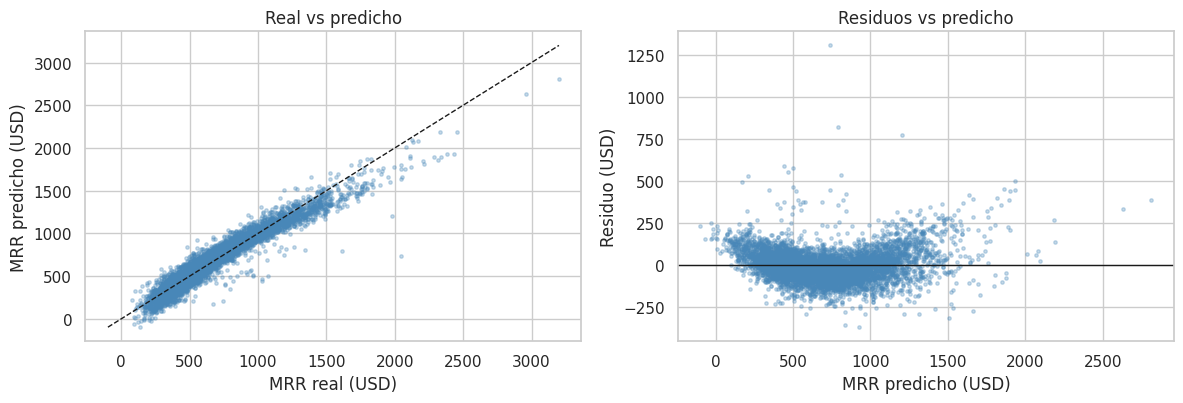

In [16]:
# --- 4.2.2 DIAGNÓSTICO DE RESIDUOS (conjunto de prueba) ---
residuos = y_test - predicciones

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(y_test, predicciones, s=6, alpha=0.3, color='#4887b8')
lim = [min(y_test.min(), predicciones.min()), max(y_test.max(), predicciones.max())]
axes[0].plot(lim, lim, 'k--', lw=1)
axes[0].set_xlabel('MRR real (USD)'); axes[0].set_ylabel('MRR predicho (USD)'); axes[0].set_title('Real vs predicho')

axes[1].scatter(predicciones, residuos, s=6, alpha=0.3, color='#4887b8')
axes[1].axhline(0, color='k', lw=1)
axes[1].set_xlabel('MRR predicho (USD)'); axes[1].set_ylabel('Residuo (USD)'); axes[1].set_title('Residuos vs predicho')
plt.tight_layout(); plt.show()

### 4.2.2 Diagnóstico de residuos

- **Real vs predicho:** los puntos siguen de cerca la diagonal, coherente con el R² ≈ 0,92.
- **Residuos vs predicho:** están centrados en cero (promedio ≈ USD 0,5). Se aprecia una leve curvatura (el modelo tiende a subestimar en los extremos y a sobrestimar en la zona media) y una mayor dispersión en los MRR predichos más altos. El supuesto lineal es razonable, pero el error es algo mayor en los clientes de mayor ingreso.

## 4.3 Variables que más impactan en el MRR futuro

La regresión lineal es interpretable: cada coeficiente es el cambio esperado en el MRR (USD) al aumentar esa variable en una unidad, **manteniendo las demás constantes**. Como las variables tienen escalas distintas, se muestran dos lecturas:

1. **Coeficiente en unidades originales** (p. ej., USD por sesión adicional, por ticket adicional).
2. **Impacto de +1 desviación estándar** de la variable (permite comparar variables entre sí).

,coef. en unidades originales (USD),impacto de +1 desv. est. (USD)
tamano_empresa,323.367,236.228
promedio_sesiones_mes,3.991,175.095
duracion_meses,11.324,86.139
pago_puntual_bin,204.258,81.156
satisfaccion_nps,21.834,47.961
gasto_mkt_asociado,0.023,32.992
tickets_soporte,-17.649,-29.433
sector_empresa_Retail,2.531,0.907
antiguedad_dias,-0.001,-0.307
sector_empresa_Finanzas,0.675,0.292


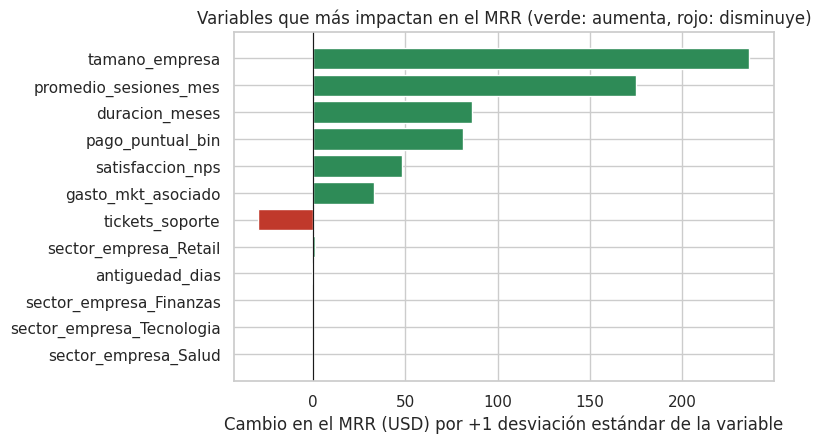

In [17]:
prep_ajustado = modelo.named_steps['preprocesar']
X_train_t = prep_ajustado.transform(X_train)
X_train_t.columns = [c.split('__', 1)[1] for c in X_train_t.columns]

nombres = list(X_train_t.columns)
coef = pd.Series(modelo.named_steps['regresion'].coef_, index=nombres)

# Coeficiente en unidades originales: las variables escaladas con RobustScaler se dividen por su IQR (scale_)
escala = pd.Series(1.0, index=nombres)
escala[CONTINUAS] = prep_ajustado.named_transformers_['continuas'].named_steps['escalar'].scale_
escala[DISCRETAS] = prep_ajustado.named_transformers_['discretas'].named_steps['escalar'].scale_
coef_orig = coef / escala

# Impacto de +1 desviación estándar de la variable (en la escala en que entra al modelo)
impacto_1sd = coef * X_train_t.std(ddof=0)

tabla_coef = pd.DataFrame({
    'coef. en unidades originales (USD)': coef_orig,
    'impacto de +1 desv. est. (USD)': impacto_1sd,
}).sort_values('impacto de +1 desv. est. (USD)', key=np.abs, ascending=False)
display(tabla_coef.round(3))

fig, ax = plt.subplots(figsize=(8, 4.6))
orden = tabla_coef['impacto de +1 desv. est. (USD)']
colores = ['#2e8b57' if v > 0 else '#c0392b' for v in orden]
ax.barh(orden.index[::-1], orden.values[::-1], color=colores[::-1])
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Cambio en el MRR (USD) por +1 desviación estándar de la variable')
ax.set_title('Variables que más impactan en el MRR (verde: aumenta, rojo: disminuye)')
plt.tight_layout(); plt.show()

### 4.3.1 Lectura de los coeficientes

Ordenadas por impacto de +1 desviación estándar (manteniendo lo demás constante); la columna «Efecto» muestra el coeficiente en unidades originales:

| # | Variable | Efecto (unidades originales) | Lectura de negocio |
| :-: | :--- | :--- | :--- |
| 1 | **Tamaño de la empresa** | ≈ **+USD 323** por escalón (Pequeña → Mediana → Grande) | Es el mayor determinante del MRR. Un cliente Grande factura ≈ USD 650 más que uno Pequeño en condiciones similares. |
| 2 | **Uso de la plataforma** (`promedio_sesiones_mes`) | ≈ **+USD 4,0** por sesión mensual adicional | El engagement es la palanca más accionable: +25 sesiones al mes se asocian a ≈ +USD 100 de MRR. |
| 3 | **Duración del contrato** | ≈ **+USD 11** por mes de compromiso (≈ +USD 260 al pasar de Mensual a 2 Años) | Los contratos largos se asocian a mayor ingreso. |
| 4 | **Pago puntual** | ≈ **+USD 204** si el cliente paga a tiempo | Los clientes que pagan a tiempo tienen un MRR esperado bastante mayor. |
| 5 | **Satisfacción (NPS)** | ≈ **+USD 22** por punto de NPS | Subir la satisfacción se asocia a más ingreso. |
| 6 | **Gasto en marketing** | ≈ **+USD 0,02** por USD invertido (≈ +USD 23 por cada USD 1.000) | Efecto positivo pero modesto. |
| 7 | **Tickets de soporte** | ≈ **−USD 18** por ticket adicional | Más incidencias se asocian a menor ingreso: señal de fricción. |
| — | **Sector** y **antigüedad** | ≈ 0 (impacto menor a USD 1 por +1 desv. est.) | Ni el sector ni el tiempo como cliente ayudan a predecir el MRR una vez conocidas las demás variables. |

**Cómo leer estos resultados con rigor:**
- Son **asociaciones**, no causas. Que las sesiones se asocien a más MRR no prueba que empujar el uso *cause* más ingreso; las acciones sugeridas deben validarse con pilotos.
- El tamaño de empresa se codifica como ordinal, lo que supone que el salto Pequeña → Mediana es igual al salto Mediana → Grande.

## 4.4 Interpretación Consolidada en el Contexto Financiero de SaaSFlow

| Métrica | Valor (prueba) | Qué significa para SaaSFlow |
| :--- | :--- | :--- |
| **R²** | ≈ **0,924** | El modelo explica ≈ 92 % de las diferencias de MRR entre clientes y se mantiene igual en clientes nuevos (R² de entrenamiento ≈ 0,919). Sirve para **priorizar y proyectar**. |
| **MAE** | ≈ **USD 68** por cliente | *El modelo se equivoca, en promedio, en aproximadamente USD 68 por cliente*, ≈ 10 % del MRR promedio (≈ USD 708). |

**Implicancias para la toma de decisiones**
1. **Planificación financiera:** el R² alto permite proyectar el ingreso del trimestre con buena confianza.
2. **Customer Success:** priorizar según *ingreso esperado y variables accionables*. Una acción por cliente se justifica cuando el ingreso en juego supera con claridad el error típico (≈ USD 68); diferencias menores están dentro del ruido del modelo.
3. **Uso individual:** para un cliente puntual, la predicción debe leerse como *"valor esperado ± USD 70"* aproximadamente.

## 4.5 Recomendaciones Estratégicas para Customer Success

Basadas en los coeficientes de la sección 4.3:

1. **Impulsar el uso de la plataforma** (mayor palanca accionable): programas de onboarding y *adoption* para clientes con pocas sesiones; alertas cuando las sesiones caigan bajo la mediana de su tamaño.
2. **Gestionar el pago puntual:** clientes con `pago_puntual = No` tienen ≈ USD 204 menos de MRR esperado. Recordatorios automáticos, débito automático o facturación anticipada.
3. **Reducir fricción de soporte:** cada ticket adicional se asocia a ≈ −USD 18. Detectar clientes con muchos tickets y resolver la causa raíz (documentación, bugs, capacitación).
4. **Migrar contratos mensuales a anuales:** el paso a contrato largo se asocia a más MRR (≈ +USD 11 por mes de compromiso). Ofrecer incentivos de renovación anticipada.
5. **Cuidar la satisfacción:** ≈ +USD 22 por punto de NPS; hacer seguimiento a clientes con NPS bajo.
6. **Asignar recursos por tamaño y valor:** los clientes Grandes concentran el mayor MRR; asignarles ejecutivos dedicados.
7. **No usar sector ni antigüedad para segmentar el MRR esperado:** no aportan una vez consideradas las demás variables. Tampoco sobredimensionar el gasto en marketing: su efecto es positivo pero modesto.
8. **Uso operativo:** ordenar la cartera por MRR predicho y revisar primero los casos donde la diferencia frente al MRR actual supera ≈ USD 70 (por encima del ruido del modelo).